In [65]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch.nn as nn

In [66]:
df = pd.read_csv("../Veriler/Iris.csv")

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [68]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [69]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [70]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

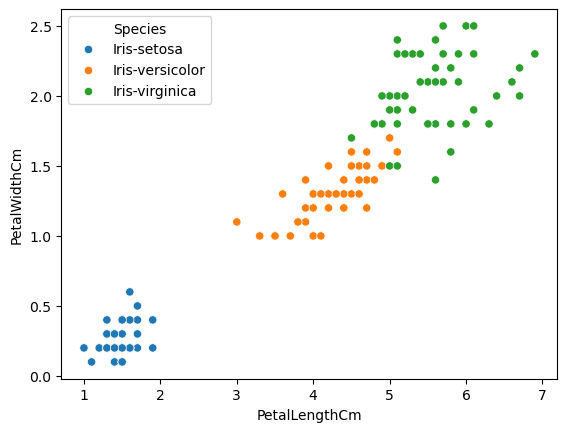

In [71]:
sns.scatterplot(x=df['PetalLengthCm'], y=df['PetalWidthCm'], hue=df["Species"])
plt.show()

In [72]:
df.drop('Id', axis=1,inplace=True)
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [73]:
x = torch.tensor(df[['SepalLengthCm',"SepalWidthCm","PetalLengthCm","PetalWidthCm"]].values, dtype=torch.float32)
y = df["Species"].values

In [74]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [75]:
# label encoding

In [76]:
from sklearn.preprocessing import LabelEncoder

In [77]:
# y'deki sınıflara birer label atıyor.
le = LabelEncoder() 
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [90]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.2,stratify=y)
# statify -> rastgele seçilirken oranın korunmasını sağlar.

In [91]:
y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)
print(y_train.shape, y_test.shape)

torch.Size([30]) torch.Size([120])


In [110]:
class MultiClassClasification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4,10),
            nn.ReLU(),
            nn.Linear(10,16),
            nn.ReLU(),
            nn.Linear(16,3),
        )
        # self.layer_1 = nn.Linear(in_features=4,out_features=10)
        # self.layer_2 = nn.Linear(in_features=10,out_features=16)
        # self.layer_3 = nn.Linear(in_features=16,out_features=3)
        # self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear_layer_stack(x)
        # return self.layer_3(self.ralu(self.layer_2(self.relu(self.layer_1(x)))))

In [111]:
model = MultiClassClasification()

In [112]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)

In [113]:
def calculate_accuracy(y_true,y_pred):
    correct = torch.eq(y_true,y_pred)
    accuracy = (correct / y_pred) *100
    return accuracy

In [108]:
torch.manual_seed(42)
epochs = 200

for epoch in range(epochs):
    model.train()
    y_logits = model(x_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    loss = loss_fn(y_logits,y_train)
    acc = calculate_accuracy(y_train,y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step() 


In [116]:
y_logit = model(x_train)
y_logit[:5]

tensor([[-0.0458, -0.4597,  0.3068],
        [ 0.2282, -0.2335, -0.2149],
        [ 0.0019, -0.3917,  0.2412],
        [ 0.0631, -0.3608,  0.1665],
        [ 0.2331, -0.2091, -0.1981]], grad_fn=<SliceBackward0>)

In [129]:
y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
y_pred

tensor([2, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2,
        0, 0, 0, 2, 2, 2])